## Ewgreaders Tutorial

Using `ewgreaders` package to load observational data from Lake Zug.

In [39]:
# imports
import ewgreaders as ewg
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

In [3]:
lake = 'Zug'

### Data Index

The data index is the catalogue of all available processed (L2) data.  Use `ewg.get_data_index` to access the data index for a given lake and datatype (i.e., ctd, mooring).

The columns of the data index provide metadata that can be used for data selection.  For example, the date and profile location for CTD profiles, or the sensor type and depth for mooring instruments.

In [6]:
di_ctd = ewg.get_data_index(lake, 'ctd')
di_ctd

,lake,date,time,profile_loc,xsc,ysc,sensor,serial_id,fname
0,Zug,2024-11-08,10:42,P9,680173,217479,sea&sun,1807,IB081320_2
1,Zug,2024-11-08,11:02,P7,680083,218327,sea&sun,1807,IB081320_3
2,Zug,2024-11-08,11:20,P6W,679942,218820,sea&sun,1807,IB081320_4
3,Zug,2024-11-08,11:34,P6,680090,218816,sea&sun,1807,IB081320_5
4,Zug,2024-11-08,11:52,P5'',679841,219294,sea&sun,1807,IB081320_6
...,...,...,...,...,...,...,...,...,...
283,Zug,2026-04-09,14:31,P6W,679931,218791,sea&sun,2023,K4101445_6
284,Zug,2026-04-09,14:54,P10,680813,216240,sea&sun,2023,K4101445_7
285,Zug,2026-04-10,10:19,P6E,680288,218845,sea&sun,2023,K4101445_8
286,Zug,2026-04-10,11:14,P6W,679912,218786,sea&sun,2023,K4101445_9


In [8]:
di_m = ewg.get_data_index(lake, 'mooring')
di_m

,lake,date,location,xsc,ysc,deploy,retrieve,sensor,serial_id,depth
0,Zug,2024-04-24,LZC,680101,218799,2024-01-04,2024-04-24,rbr_temp,205515,130.9
1,Zug,2024-04-24,LZC,680101,218799,2024-01-04,2024-04-24,adcp,16576,137.3
2,Zug,2024-04-24,LZC,680101,218799,2024-01-04,2024-04-24,adcp,24399,137.3
3,Zug,2024-04-24,LZC,680101,218799,2024-01-04,2024-04-24,rbr_duet,82133,137.3
4,Zug,2024-04-24,LZC,680101,218799,2024-01-04,2024-04-24,rbr_temp,209292,140.9
...,...,...,...,...,...,...,...,...,...,...
321,Zug,2026-04-09,LZW,679917,218754,2026-02-05,2026-04-10,minidot,117137,133.4
322,Zug,2026-04-09,LZW,679917,218754,2026-02-05,2026-04-10,rbr_temp,205513,133.4
323,Zug,2026-04-09,LZW,679917,218754,2026-02-05,2026-04-10,minidot,587731,138.8
324,Zug,2026-04-09,LZW,679917,218754,2026-02-05,2026-04-10,rbr_temp,209301,138.8


### Data Loading

Each row of the data index corresponds to a processed data file.  To load the data, simply pass the required metadata from the data index to instantiate the appropriate reader:

- CTD: `ewg.ctd_reader.CTDReader(lake, date, fname)`
- ADCP: `ewg.adcp_reader.ADCPReader(lake, date, location, serial_id)`
- Thermistor: `ewg.thermistor_reader.ThermistorReader(lake, date, location, serial_id)`
- Oxygen Logger: `ewg.o2_reader.O2Reader(lake, date, location, serial_id)`

Then, use the reader's `load()` method to access the data.

There is also a `MooringReader` class with useful methods.

- Mooring: `ewg.mooring_reader.MooringReader(lake, date, location)`

In [18]:
# load CTD profile
date = '2026-01-13'
pl = 'VMPC'
di_ctd_sel = di_ctd.query("date == @date and profile_loc == @pl")
display(di_ctd_sel)

p = di_ctd_sel.iloc[0]    # select 1 profile

,lake,date,time,profile_loc,xsc,ysc,sensor,serial_id,fname
191,Zug,2026-01-13,12:15,VMPC,680120,218743,sea&sun,1807,K1131806_2
192,Zug,2026-01-13,13:37,VMPC,680107,218629,sea&sun,1807,K1131806_3
195,Zug,2026-01-13,16:23,VMPC,680144,218638,sea&sun,1807,K1131806_6


In [19]:
# instantiate CTDReader object
ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)

# load processed data
ds_ctd = ctdreader.load()
ds_ctd

<xarray.Dataset> Size: 632kB
Dimensions:     (depth: 4646)
Coordinates:
    time        (depth) datetime64[ns] 37kB ...
  * depth       (depth) float64 37kB 0.5334 0.5513 0.5835 ... 143.6 143.6 143.6
Data variables: (12/15)
    press       (depth) float64 37kB ...
    temp        (depth) float64 37kB ...
    cond        (depth) float64 37kB ...
    cond25      (depth) float64 37kB ...
    turb        (depth) float64 37kB ...
    do2_sat     (depth) float64 37kB ...
    ...          ...
    salin       (depth) float64 37kB ...
    cond20      (depth) float64 37kB ...
    rho         (depth) float64 37kB ...
    ptemp       (depth) float64 37kB ...
    prho        (depth) float64 37kB ...
    fall_speed  (depth) float64 37kB ...
Attributes: (12/22)
    project:        IBEX
    captain:        Haydn Herrema
    crew:           Tomy Doda
    lake:           Zug
    altitude:       417
    date:           2026-01-13
    ...             ...
    wind_strength:  
    drift:          N
    boat_moving:    True
    stop:           []
    bottom:         False
    comments:       winch slow; move boat at 115 m

In [27]:
# load ADCP data
date = '2026-04-09'
loc = 'LZW'
di_m_sel = di_m.query("date == @date and location == @loc and sensor == 'adcp'")
display(di_m_sel)

# select row
row = di_m_sel.iloc[0]

,lake,date,location,xsc,ysc,deploy,retrieve,sensor,serial_id,depth
325,Zug,2026-04-09,LZW,679917,218754,2026-02-05,2026-04-10,adcp,16576,141.2


In [36]:
# instantiate ADCPReader object
areader = ewg.adcp_reader.ADCPReader(row.lake, row.date, row.location, row.serial_id)

# load processed data
ds_adcp = areader.load()

# instantiate MooringReader object
mreader = ewg.mooring_reader.MooringReader(row.lake, row.date, row.location)

# get metadata about mooring deployment, use to filter
deploy, retrieve = mreader.get_deploy_retrieve_dates()
t_start = deploy + pd.Timedelta(days=1)
t_end = retrieve - pd.Timedelta(days=1)
ds_adcp = ds_adcp.sel(time=slice(t_start, t_end))

ds_adcp

<xarray.Dataset> Size: 38MB
Dimensions:            (time: 8928, depth: 13, dir: 4, beam: 4, x: 4, x*: 4,
                        earth: 3, inst: 3)
Coordinates:
  * time               (time) datetime64[ns] 71kB 2026-02-06T00:06:08.0299999...
  * dir                (dir) <U3 48B 'E' 'N' 'U' 'err'
    range              (depth) float64 104B ...
  * beam               (beam) int64 32B 1 2 3 4
  * x                  (x) int64 32B 1 2 3 4
  * x*                 (x*) int64 32B 1 2 3 4
  * earth              (earth) <U1 12B 'E' 'N' 'U'
  * inst               (inst) <U1 12B 'X' 'Y' 'Z'
  * depth              (depth) float64 104B 131.0 129.0 127.0 ... 109.0 107.0
    serial_id          <U5 20B ...
Data variables: (12/20)
    builtin_test_fail  (time, depth) float64 929kB ...
    c_sound            (time, depth) float32 464kB ...
    z                  (time, depth) float32 464kB ...
    pitch              (time, depth) float32 464kB ...
    roll               (time, depth) float32 464kB ...
    heading            (time, depth) float32 464kB ...
    ...                 ...
    vel                (dir, depth, time) float32 2MB ...
    amp                (beam, depth, time) float32 2MB ...
    corr               (beam, depth, time) float32 2MB ...
    prcnt_gd           (beam, depth, time) float32 2MB ...
    rotmat             (x, x*, time, depth) float64 15MB ...
    orientmat          (earth, inst, time, depth) float64 8MB ...
Attributes: (12/47)
    inst_make:                TRDI
    inst_type:                ADCP
    rotate_vars:              vel
    has_imu:                  0
    prog_ver:                 51.4
    inst_model:               Workhorse
    ...                       ...
    deployment:               05.02.2026
    retrieval:                10.04.2026
    sensor:                   adcp
    serial_id:                16576
    depth:                    141.1999969482422
    orientation:              up

### Instrument Chains

To load multiple instruments from the same mooring, we can use the `create_instrument_chain` method from the `MooringReader` class.

In [32]:
# thermistor chain
date = '2026-04-09'
loc = 'LZW'
thermistors = ['rbr_temp', 'rbr_duet']
di_m_sel = di_m.query("date == @date and location == @loc and sensor in @thermistors")
di_m_sel

,lake,date,location,xsc,ysc,deploy,retrieve,sensor,serial_id,depth
310,Zug,2026-04-09,LZW,679917,218754,2026-02-05,2026-04-10,rbr_duet,81465,100.3
312,Zug,2026-04-09,LZW,679917,218754,2026-02-05,2026-04-10,rbr_temp,205532,106.4
314,Zug,2026-04-09,LZW,679917,218754,2026-02-05,2026-04-10,rbr_temp,200579,111.8
316,Zug,2026-04-09,LZW,679917,218754,2026-02-05,2026-04-10,rbr_temp,203320,117.2
318,Zug,2026-04-09,LZW,679917,218754,2026-02-05,2026-04-10,rbr_duet,82133,124.2
320,Zug,2026-04-09,LZW,679917,218754,2026-02-05,2026-04-10,rbr_temp,200568,128.0
322,Zug,2026-04-09,LZW,679917,218754,2026-02-05,2026-04-10,rbr_temp,205513,133.4
324,Zug,2026-04-09,LZW,679917,218754,2026-02-05,2026-04-10,rbr_temp,209301,138.8


In [38]:
# instantiate mooring reader
mreader = ewg.mooring_reader.MooringReader(lake, pd.to_datetime(date), loc)    # date needs to be correct type

# load all thermistors
all_ds = []
for _, row in di_m_sel.iterrows():
    treader = ewg.thermistor_reader.ThermistorReader(row.lake, row.date, row.location, row.serial_id)
    ds = treader.load()
    all_ds.append(ds)

# all sensors in single xarray dataset
ds_temp = mreader.create_instrument_chain(all_ds)

ds_temp

<xarray.Dataset> Size: 77MB
Dimensions:    (depth: 8, time: 568573)
Coordinates:
  * time       (time) datetime64[ns] 5MB 2026-02-03T15:45:20 ... 2026-04-10T1...
  * depth      (depth) float64 64B 100.3 106.4 111.8 117.2 ... 128.0 133.4 138.8
    serial_id  (depth) <U6 192B '081465' '205532' '200579' ... '205513' '209301'
Data variables:
    temp       (depth, time) float64 36MB 20.15 20.14 20.12 ... 5.488 5.485
    press      (depth, time) float64 36MB 9.47 9.469 9.468 9.469 ... nan nan nan
Attributes:
    location:     LZW
    xsc:          679917
    ysc:          218754
    lake_depth:   121
    bathy_depth:  147.69
    deployment:   05.02.2026
    retrieval:    10.04.2026
    sensor:       rbr_duet
    serial_id:    081465
    depth:        100.3
    t_offset:     None

### Analysis

The `ewgreaders` package contains data analysis methods, found in 

- `ewg.datsci.lakes`
- `ewg.datsci.efd`
- `ewg.datsci.signal`

In [46]:
# 1-meter rolling average on CTD density profile
rho = ds_ctd['rho']
rho_ra = ewg.signal.rolling_average_z(rho)

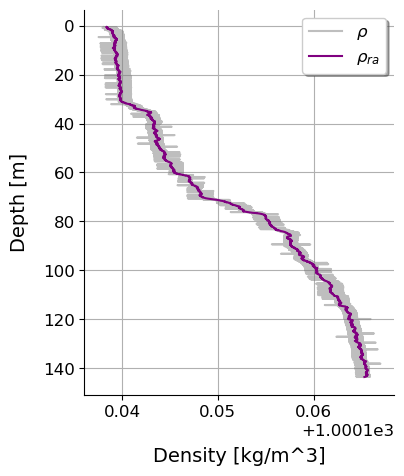

In [58]:
fig, ax = plt.subplots(figsize=(4, 5))

sns.lineplot(x=rho, y=rho.depth, orient='y', color='tab:gray', alpha=0.5, ax=ax, label=r'$\rho$')
sns.lineplot(x=rho_ra, y=rho_ra.depth, orient='y', color='purple', ax=ax, label=r'$\rho_{ra}$')

ax.set_xlabel('Density [kg/m^3]', fontsize=14, labelpad=20)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)
ax.xaxis.get_offset_text().set_fontsize(12)

ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)

ax.invert_yaxis()
ax.legend(fontsize=12, shadow=True)

plt.show()